In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

print("Python:", sys.version)
print("Projeto:", PROJECT_ROOT)
print("SRC:", SRC_PATH)

import plotly.io as pio
pio.renderers.default = "notebook_connected+png"

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Projeto: c:\GitHub\datascience\projetos\concessao_credito
SRC: c:\GitHub\datascience\projetos\concessao_credito\src


In [2]:
import pandas as pd
import numpy as np
import sklearn
import plotly
import seaborn as sns
import matplotlib

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("plotly:", plotly.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 3.0.3
numpy: 2.4.6
sklearn: 1.9.0
plotly: 6.8.0
seaborn: 0.13.2
matplotlib: 3.11.0


In [3]:
from concessao_credito.config import CONCESSAO_PATH, INADIMPLENCIA_PATH

print("Concessao existe?", CONCESSAO_PATH.exists(), CONCESSAO_PATH)
print("Inadimplencia existe?", INADIMPLENCIA_PATH.exists(), INADIMPLENCIA_PATH)

Concessao existe? True C:\GitHub\datascience\projetos\concessao_credito\data\raw\concessao.csv
Inadimplencia existe? True C:\GitHub\datascience\projetos\concessao_credito\data\raw\inadimplencia.csv


In [4]:
concessao = pd.read_csv(CONCESSAO_PATH)
inadimplencia = pd.read_csv(INADIMPLENCIA_PATH)

display(concessao.head())
display(inadimplencia.head())

print("Shape concessao:", concessao.shape)
print("Shape inadimplencia:", inadimplencia.shape)

,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta
0,1,2021-12-28,4449.81,621.66,0.048425,9,3574.32,42.11,Fundamental Completo,1,78,1968-03-14,2019-09-04
1,2,2020-10-02,12822.78,1119.39,0.035763,15,4140.87,5.21,Médio Incompleto,1,89,1975-08-01,2019-12-06
2,3,2020-10-01,11683.15,1540.47,0.035673,9,2505.74,0.00,Médio Incompleto,1,61,1988-05-03,2019-10-22
3,4,2022-02-10,9704.14,1844.53,0.038896,6,5895.24,59.26,Não Declarado,0,11,1990-05-15,2020-09-21
4,5,2022-04-05,17875.28,3937.49,0.033076,5,6437.35,38.02,Não Declarado,1,69,1968-08-16,2020-10-19


,id_cliente,data_referencia,flag_inadimplente
0,1,2022-01-31,0
1,1,2022-02-28,0
2,1,2022-03-31,0
3,1,2022-04-30,0
4,1,2022-05-31,0


Shape concessao: (30000, 13)
Shape inadimplencia: (257960, 3)


In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

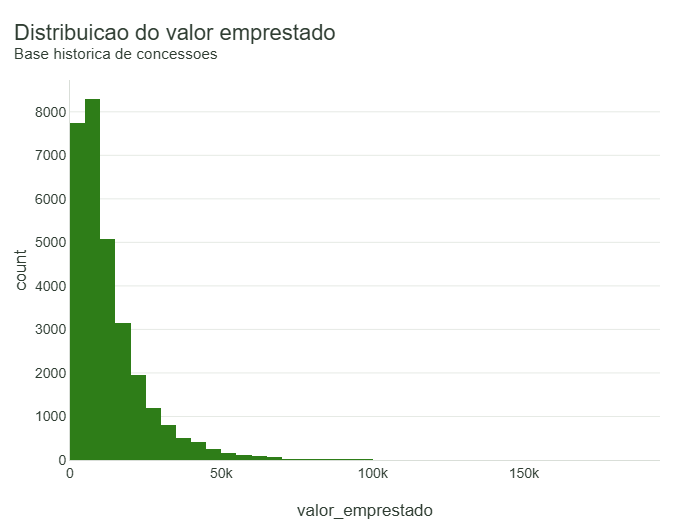

In [6]:
import plotly.express as px
from concessao_credito.plots import registrar_template_credito, aplicar_layout

registrar_template_credito()

fig = px.histogram(
    concessao,
    x="valor_emprestado",
    nbins=40,
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do valor emprestado",
    subtitulo="Base historica de concessoes",
    mostrar_legenda=False,
)

fig.show()